# **Taxi Fare Prediction**
## Weekly Class AI/ML Advanced - Final Project
---

<br>

### 😎 **Group 3** 😎
1. Danish Syach Burhan
2. Muhammad Aulia Addinul Haq
3. Muhamad Azvar Al Hasan
4. Muhammad Faiqul Umam Dzunnuroeni
5. Muhammad Zaky Ramadhan
6. Azwar Riansyah
7. Bariza Rafi Leressae
8. Daffa Fahrezi Purdyansyah

<br>

### 🧐 **Case** 🧐
Dalam industri ride-hailing (transportasi online) dan taksi modern, transparansi harga adalah kunci untuk mendapatkan kepercayaan pelanggan. Pelanggan sering kali merasa ragu untuk memesan perjalanan jika mereka tidak tahu perkiraan biaya yang harus mereka keluarkan, terutama pada jam sibuk atau rute jarak jauh.

Sebagai seorang Machine Learning Engineer di sebuah perusahaan transportasi, Anda ditugaskan untuk membangun fitur "Upfront Pricing" (Estimasi Harga di Muka). Anda harus membangun sebuah aplikasi web cerdas berbasis model Regresi yang mampu memprediksi tarif taksi berdasarkan waktu penjemputan, lokasi penjemputan, lokasi tujuan, dan jumlah penumpang. Aplikasi ini nantinya akan disimulasikan sebagai antarmuka pelanggan di smartphone mereka, di mana mereka bisa melihat estimasi harga sebelum menekan tombol "Pesan Sekarang".

<br>

### 📚 **Dataset** 📚
[Taxi_Fare_Prediction](https://www.kaggle.com/datasets/gajendrasharma118/taxi-fare-prediction)

Owner of the Dataset (@ Kaggle):
* *Gajendra Sharma*

<br>

### 💬 **Dataset's Description** 💬
This dataset tries to address the challenges faced by taxi operators in quoting the right fare to customers before starting the trip. However, the details are shared with taxi drivers or operators related to the trip, they find it difficult to quote the right fare because of uncertainties and calculation complexities.

The same issue is faced by passengers as well because of inaccurate or irrelevant fares quoted. To find a solution for this, this historical dataset that includes records of taxi trip details and fares of those trips, poses an interesting opportunity for Data Scientists.

Using this dataset, they can build machine learning models for predicting the trip fare based on the given other useful features of the trip. This project solves a lot of problems faced both by Taxi operators and the customers taking the trip.

<br>

### 📍 **Dataset's Features** 📍
* `trip_distance`
* `rate_code`
* `store_and_fwd_flag`
* `payment_type`
* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `imp_surcharge`
* `total_amount`
* `pickup_location_id`
* `dropoff_location_id`
* `year`
* `month`
* `day`
* `day_of_week`
* `hour_of_day`
* `trip_duration`
* `calculated_total_amount`

<br>

### 📝 **NOTE** 📝
- Notebook ini merupakan tempat kalian melatih model yang akan kalian deploy melalui streamlit, notebook ini mencakup EDA hingga Model Serialization
- Kalian boleh mengikuti template pengerjaan kode di bawah yang sudah disiapkan oleh core team. Jika kalian memiliki preferensi pengerjaan kode sendiri, feel free untuk diubah yaaa
- Semangat 💪🔥

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = 'https://raw.githubusercontent.com/AL-Qudzzz/data_taxi-fare/refs/heads/main/taxi_fare.csv'

# Membaca data dari file CSV
df = pd.read_csv(url)
df

,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id,year,month,day,day_of_week,hour_of_day,trip_duration,calculated_total_amount
0,9.01,1,N,1,26.0,0.0,0.5,8.14,5.76,0.3,40.70,262,138,2018,3,7,2,6,2131.0,24.30
1,0.20,1,N,1,3.0,0.0,0.5,0.75,0.00,0.3,4.55,263,236,2018,2,25,6,10,2377.0,37.40
2,9.65,1,N,1,41.5,0.0,0.5,9.61,5.76,0.3,57.67,138,230,2018,1,29,0,8,1286.0,30.36
3,9.50,1,N,1,30.0,0.5,0.5,9.25,5.76,0.3,46.31,186,138,2018,9,25,1,20,2586.0,4.30
4,5.80,1,N,1,21.5,0.5,0.5,4.56,0.00,0.3,27.36,162,87,2018,8,20,0,21,1575.0,23.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,22.43,1,N,1,59.5,0.5,0.5,10.00,5.76,0.3,76.56,132,259,2018,5,23,2,23,2998.0,29.76
34996,9.16,1,N,1,30.0,0.0,0.5,6.58,5.76,0.3,43.14,24,138,2018,4,4,2,9,1419.0,29.15
34997,6.78,1,N,1,23.0,0.0,0.5,5.95,0.00,0.3,29.75,140,231,2018,3,7,2,8,2459.0,42.67
34998,0.26,1,N,2,3.0,0.0,0.5,0.00,0.00,0.3,3.80,142,142,2018,4,18,2,8,1932.0,26.73


### 📊 Preprocessing

#### Data Cleaning

In [28]:
print(f"Dimensi data awal: {df.shape}\n")

# 1. Analisis & Menghapus Baris Duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"-> Menghapus {jumlah_duplikat} baris duplikat.")
df = df.drop_duplicates()

# 2. Analisis & Menghapus Nilai Kosong (Missing Values)
missing_data = df.isnull().sum().max()
print(f"-> Menghapus {missing_data} baris dengan nilai kosong (NaN).")
df = df.dropna()

# 3. Menghapus Outlier & Data Tidak Logis (Sanity Checks Tingkat Lanjut)
awal_row = len(df)

# a. Filter Harga: Minimal $2.5 (tarif dasar standar taksi) dan maksimal $500 (mencegah anomali)
df = df[(df['fare_amount'] >= 2.5) & (df['fare_amount'] <= 500)]

# b. Filter Jarak: Jarak harus logis (lebih dari 0 dan kurang dari 100 mil untuk dalam kota/bandara)
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] <= 100)]

# c. Validasi Rate Code: Hanya menyimpan rate_code standar operasional (1 sampai 6)
valid_rate_codes = [1, 2, 3, 4, 5, 6]
df = df[df['rate_code'].isin(valid_rate_codes)]

# d. Validasi Waktu: Memastikan jam berada di rentang yang benar (0-23)
df = df[(df['hour_of_day'] >= 0) & (df['hour_of_day'] <= 23)]

baris_dibuang = awal_row - len(df)
print(f"-> Menghapus {baris_dibuang} baris anomali tidak logis (outlier).")

df.reset_index(drop=True, inplace=True)

print(f"\nDimensi data akhir setelah dibersihkan: {df.shape}")

Dimensi data awal: (35000, 20)

-> Menghapus 0 baris duplikat.
-> Menghapus 0 baris dengan nilai kosong (NaN).
-> Menghapus 7 baris anomali tidak logis (outlier).

Dimensi data akhir setelah dibersihkan: (34993, 20)


### **Kesimpulan Data Cleaning:**
1. **Integritas Data:** Tidak ditemukan baris duplikat atau nilai kosong (*missing values*) pada dataset, sehingga kualitas data secara struktural sangat baik.
2. **Validasi Logika & Outlier:** Dilakukan penyaringan ketat untuk menghapus data yang tidak masuk akal secara operasional, yaitu:
   - Memastikan `fare_amount` berada di rentang wajar ($2.5 - $500).
   - Memastikan `trip_distance` positif dan tidak melebihi 100 mil.
   - Memastikan `rate_code` dan `hour_of_day` berada dalam kategori yang valid.
3. **Hasil Akhir:** Sebanyak **7 baris anomali** berhasil diidentifikasi dan dihapus. Dataset kini bersih dan siap digunakan untuk tahap analisis selanjutnya dengan total **34.993 baris**.

*   Menghapus data dengan `fare_amount` di bawah $2.5 penting karena itu adalah tarif bendera (*flag drop*) minimum di banyak wilayah operasional. Data di bawah nilai ini dianggap sebagai kesalahan input sistem yang dapat mengacaukan garis regresi model.
*  Filter pada `rate_code` (1-6) memastikan model hanya belajar dari skenario perjalanan standar (seperti tarif kota, bandara, atau negosiasi resmi). Menghapus kode di luar itu mencegah model mempelajari 'kasus khusus' yang jarang terjadi dan tidak relevan untuk prediksi harga umum.
*   Dengan memastikan `trip_distance` > 0, kita membuang data perjalanan yang dibatalkan namun tetap tercatat di sistem, sehingga model fokus pada hubungan nyata antara jarak tempuh dan biaya.

#### EDA

In [29]:
# Seleksi Fitur (Mencegah Data Leakage)
features_to_drop = [
    'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'imp_surcharge',
    'total_amount', 'calculated_total_amount', 'trip_duration',
    'payment_type', 'store_and_fwd_flag'
]
df_final = df.drop(columns=features_to_drop, errors='ignore')

# Memisahkan Fitur (X) dan Target (y)
X = df_final.drop(columns=['fare_amount'])
y = df_final['fare_amount']

print("Fitur yang digunakan:", X.columns.tolist())

Fitur yang digunakan: ['trip_distance', 'rate_code', 'pickup_location_id', 'dropoff_location_id', 'year', 'month', 'day', 'day_of_week', 'hour_of_day']


### **Seleksi Fitur & Pencegahan Data Leakage**

Kita menghapus fitur yang menyebabkan **Data Leakage** (informasi yang baru muncul *setelah* perjalanan selesai) agar model relevan untuk estimasi harga di muka:

*   **Biaya Tambahan & Pajak:** (`tip_amount`, `tolls_amount`, `mta_tax`, dll) — Tidak diketahui sebelum penumpang berangkat.
*   **Variabel Target:** (`total_amount`) — Mengandung nilai yang ingin diprediksi.
*   **Durasi:** (`trip_duration`) — Baru diketahui pasti saat sampai di tujuan.
*   **Informasi Teknis:** (`payment_type`, `flag`) — Tidak mempengaruhi nilai dasar tarif.

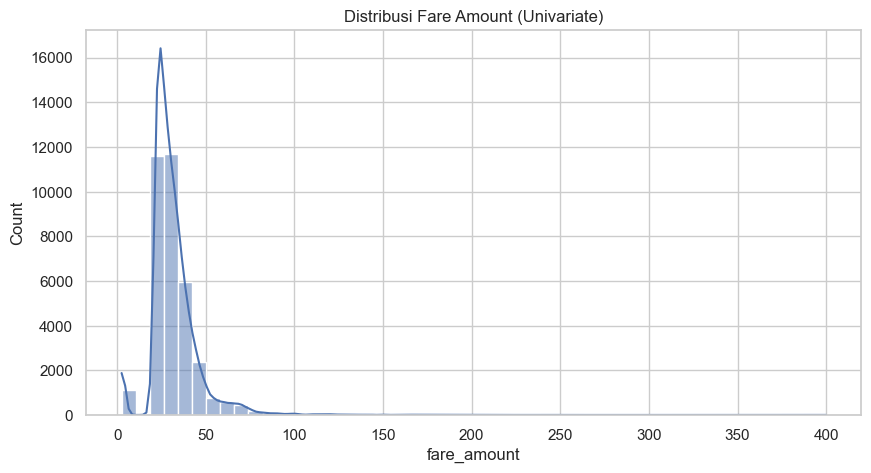

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(df['fare_amount'], bins=50, kde=True)
plt.title('Distribusi Fare Amount (Univariate)')
plt.savefig('../assets/fare_amount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### **Insight Univariate Analysis: Melihat distribusi tarif taksi**
* **Distribusi Tarif:** Mayoritas perjalanan memiliki tarif di kisaran rendah hingga menengah ($5 - 20).
* **Skewness:** Data memiliki kemiringan ke kanan (*positive skew*), yang berarti ada sebagian kecil perjalanan dengan tarif sangat tinggi (long-tail), kemungkinan besar merupakan perjalanan antar kota atau rute khusus bandara (jarak jauh).

Sebagian besar tarif terkonsentrasi pada nilai yang rendah (di bawah $20). Terdapat long-tail distribution (kemiringan ke kanan) yang mengindikasikan adanya beberapa perjalanan jarak jauh dengan tarif yang sangat tinggi.

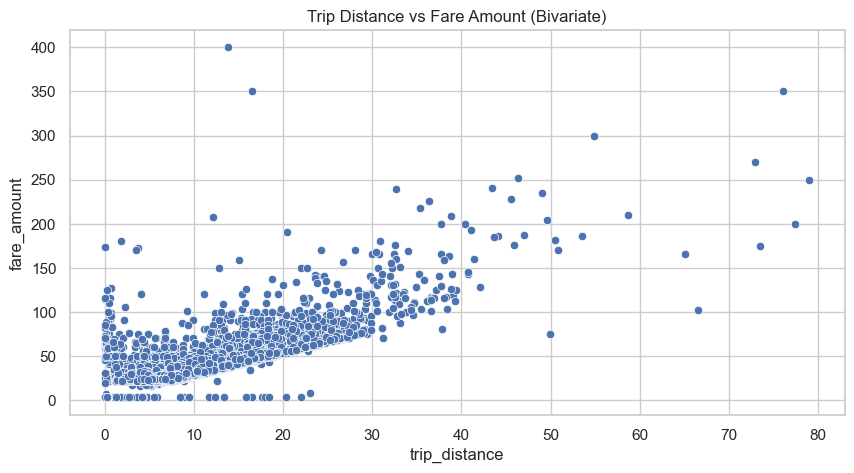

In [31]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
plt.title('Trip Distance vs Fare Amount (Bivariate)')
plt.savefig('../assets/trip_distance_vs_fare.png', dpi=300, bbox_inches='tight')
plt.show()

### **Insight Bivariate Analysis: Hubungan jarak tempuh dan tarif**
* **Hubungan Linier:** Terdapat korelasi positif yang sangat kuat antara `trip_distance` dan `fare_amount`. Semakin jauh jarak, semakin tinggi harganya.
* **Variasi Harga:** Pada jarak yang sama, terdapat variasi harga yang berbeda. Hal ini mengindikasikan adanya pengaruh faktor lain seperti durasi perjalanan (kemacetan) atau perbedaan `rate_code` (tarif dasar).

Secara umum, semakin jauh jarak perjalanan (`trip_distance`), semakin tinggi tarif yang dikenakan (`fare_amount`). Hal ini menunjukkan hubungan linier yang kuat, meskipun terdapat variasi akibat faktor lain seperti kemacetan atau tarif khusus (rate code)

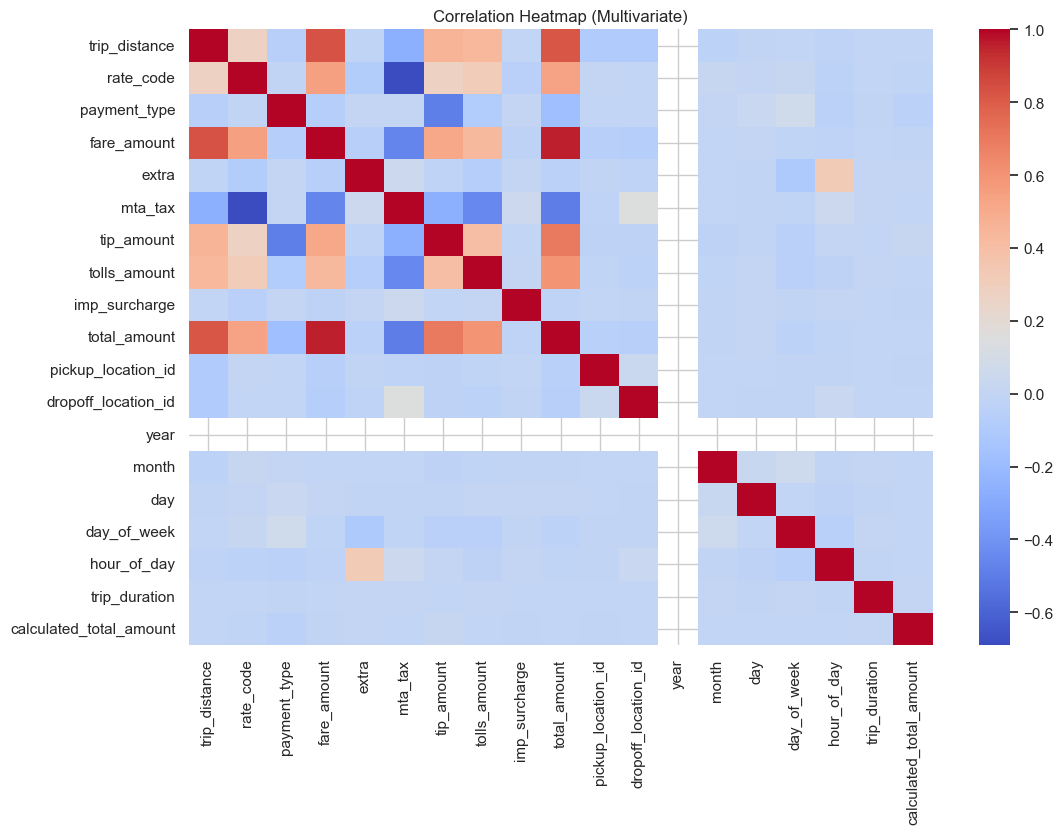

In [32]:
plt.figure(figsize=(12,8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap (Multivariate)')
plt.savefig('../assets/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### **Insight Multivariate Analysis (Heatmap):  korelasi antar fitur numerik**
* **Prediktor Utama:** `trip_distance` adalah fitur yang paling berpengaruh terhadap target `fare_amount`.
* **Fitur Pendukung:** Variabel waktu (`hour_of_day`, `day_of_week`) memiliki korelasi linier rendah secara langsung, sehingga kita membutuhkan model Machine Learning (seperti Random Forest) yang mampu mengekstrak pola non-linear dari waktu dan lokasi.

Heatmap mengonfirmasi bahwa `trip_distance` memiliki korelasi positif yang sangat tinggi dengan `fare_amount`. Variabel waktu seperti `hour_of_day` atau `day_of_week` memiliki korelasi linier yang rendah, sehingga kita membutuhkan model Machine Learning (seperti Random Forest) yang mampu mengekstrak pola non-linear dari waktu dan lokasi.

In [33]:
bins = [-1, 6, 12, 18, 24]
labels = ['Malam_DiniHari', 'Pagi', 'Siang_Sore', 'Malam']
df['time_of_day'] = pd.cut(df['hour_of_day'], bins=bins, labels=labels)
print(df[['hour_of_day', 'time_of_day']].head())

   hour_of_day     time_of_day
0            6  Malam_DiniHari
1           10            Pagi
2            8            Pagi
3           20           Malam
4           21           Malam


### **Kesimpulan EDA & Feature Selection:**
1. **Pencegahan Data Leakage:** Fitur seperti `tip_amount`, `tolls_amount`, dan `trip_duration` dihapus karena informasi ini baru diketahui *setelah* perjalanan selesai, sehingga tidak bisa digunakan untuk prediksi harga di muka (*upfront pricing*).
2. **Korelasi:** `trip_distance` terbukti menjadi prediktor terkuat bagi `fare_amount`.
3. **Feature Creation:** Variabel `hour_of_day` dikelompokkan (binning) menjadi `time_of_day` untuk menangkap fenomena perubahan tarif berdasarkan periode waktu (Pagi/Siang/Malam).

**Diskritisasi Data:**
Mengubah `hour_of_day` menjadi kategori waktu (Pagi, Siang, Malam) untuk mempermudah model menangkap pola kepadatan lalu lintas (Rush hour).

### Handling Outlier (IQR Capping)

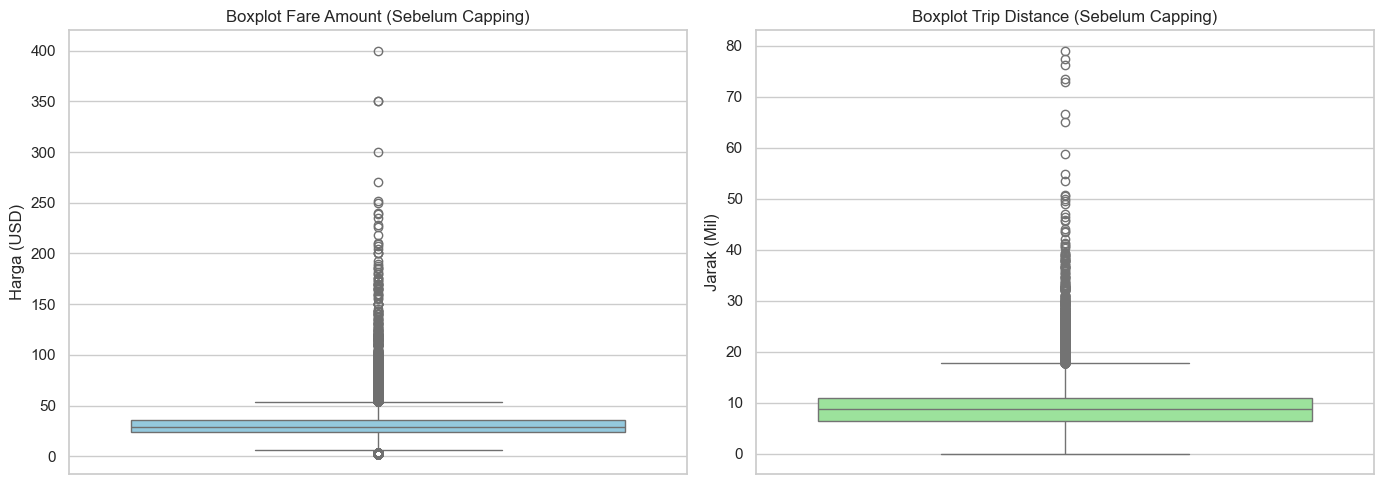

In [34]:
# Mengatur style seaborn
sns.set_theme(style="whitegrid")

# Pengecekan Outlier pada Fitur Numerik Utama
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['fare_amount'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot Fare Amount (Sebelum Capping)')
axes[0].set_ylabel('Harga (USD)')

sns.boxplot(y=df['trip_distance'], color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot Trip Distance (Sebelum Capping)')
axes[1].set_ylabel('Jarak (Mil)')

plt.tight_layout()
plt.show()

**Penjelasan:**

Boxplot ini menunjukkan sebaran data asli. Titik-titik di luar garis (whiskers) mengonfirmasi adanya nilai ekstrem pada tarif dan jarak yang berpotensi menarik garis regresi menjauh dari tren data yang sebenarnya.

In [35]:
# Fungsi untuk melakukan Capping menggunakan metode IQR
def cap_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    # Menentukan batas bawah dan atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping: Mengganti nilai di luar batas dengan nilai batasnya menggunakan np.where
    dataframe[column] = np.where(
        dataframe[column] > upper_bound, upper_bound,
        np.where(dataframe[column] < lower_bound, lower_bound, dataframe[column])
    )

    print(f"[{column}] - Batas Bawah: {lower_bound:.2f} | Batas Atas: {upper_bound:.2f}")
    return dataframe

# Menerapkan fungsi pada fitur numerik
print("=== Proses Capping Outlier (IQR) ===")
fitur_numerik = ['fare_amount', 'trip_distance']

for col in fitur_numerik:
    df = cap_outliers_iqr(df, col)

print("Capping selesai!")

=== Proses Capping Outlier (IQR) ===
[fare_amount] - Batas Bawah: 6.00 | Batas Atas: 54.00
[trip_distance] - Batas Bawah: -0.31 | Batas Atas: 17.77
Capping selesai!


**Penjelasan:**

Fungsi ini menerapkan logika statistik IQR. Nilai yang melebihi batas atas ($54.00 untuk tarif dan 17.77 mil untuk jarak) diganti menjadi nilai batas tersebut. Strategi ini menjaga integritas data tanpa membuang informasi jumlah perjalanan.

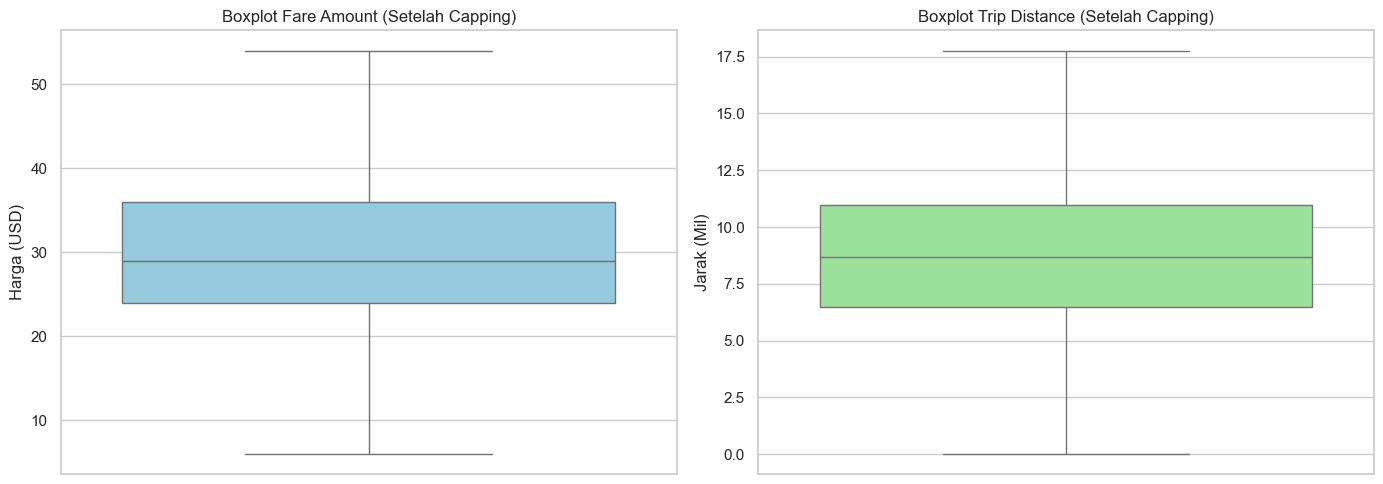

In [11]:
# Visualisasi setelah Handling (Capping)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['fare_amount'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot Fare Amount (Setelah Capping)')
axes[0].set_ylabel('Harga (USD)')

sns.boxplot(y=df['trip_distance'], color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot Trip Distance (Setelah Capping)')
axes[1].set_ylabel('Jarak (Mil)')

plt.tight_layout()
plt.show()

**Penjelasan:**

Visualisasi akhir menunjukkan distribusi yang jauh lebih bersih. Dengan hilangnya titik-titik ekstrem, model Machine Learning akan lebih mudah menemukan pola hubungan yang stabil antara jarak tempuh dan harga.

### **Kesimpulan Handling Outlier (IQR Capping):**

Dalam dataset ini, kita menemukan beberapa data ekstrem (outlier) pada fitur `fare_amount` dan `trip_distance`. Alih-alih menghapusnya, kita menggunakan metode **IQR Capping**:

1. **Visualisasi Awal (Boxplot Sebelum Capping):** Digunakan untuk mendeteksi sebaran data. Terlihat banyak titik di luar garis 'whisker' yang menunjukkan nilai ekstrem pada `fare_amount` dan `trip_distance` yang dapat mengganggu akurasi model.

2.  **Metode IQR:** Kita menetapkan batas bawah (Q1 - 1.5*IQR) dan batas atas (Q3 + 1.5*IQR). Berdasarkan perhitungan, batas atas tarif adalah **$54.00** dan jarak adalah **17.77 mil**.

3.  **Mengapa Capping?** Menghapus semua outlier dapat menghilangkan informasi berharga. Dengan capping, nilai yang melebihi batas atas akan "ditarik" ke nilai maksimum yang diizinkan. Ini mencegah model regresi terdistorsi oleh angka ekstrem (seperti tarif yang sangat mahal akibat kesalahan sistem).

4.  **Dampak:** Visualisasi boxplot setelah capping menunjukkan distribusi yang lebih rapat dan bersih. Data sekarang terkumpul dalam rentang yang logis, hal ini akan membantu dalam proses training model Machine Learning  (terutama Linear Regression) untuk bekerja lebih stabil dan memiliki error (RMSE) yang lebih rendah.

### Feature Engineering

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Memilih fitur/kolom untuk mencegah data leakage
features = ['trip_distance', 'pickup_location_id', 'dropoff_location_id', 'day_of_week', 'time_of_day']
X = df[features]
y = df['fare_amount']

numeric_features = ['trip_distance']
categorical_features = ['pickup_location_id', 'dropoff_location_id', 'day_of_week', 'time_of_day']

# Imputation & Normalisasi
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Imputation & Transformasi One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


### **Pengecekan Dimensi Fitur**
Logika pengecekan ini penting untuk melihat apakah *One-Hot Encoding* pada `location_id` membuat dataset terlalu lebar, yang bisa menyebabkan model *overfitting* atau lambat.

In [37]:
# Pastikan fitur sudah didefinisikan
features_check = ['trip_distance', 'pickup_location_id', 'dropoff_location_id', 'day_of_week', 'time_of_day']
X_check = df[features_check]

# Definisikan ulang preprocessor untuk pengecekan mandiri
numeric_features = ['trip_distance']
categorical_features = ['pickup_location_id', 'dropoff_location_id', 'day_of_week', 'time_of_day']

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor_eval = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)])

# Jalankan transformasi
X_transformed = preprocessor_eval.fit_transform(X_check)

print(f"Jumlah fitur sebelum encoding: {X_check.shape[1]}")
print(f"Jumlah fitur setelah encoding: {X_transformed.shape[1]}")

# Menampilkan fitur kategorik unik
for col in categorical_features:
    print(f"Jumlah kategori unik di {col}: {X_check[col].nunique()}")

Jumlah fitur sebelum encoding: 5
Jumlah fitur setelah encoding: 481
Jumlah kategori unik di pickup_location_id: 216
Jumlah kategori unik di dropoff_location_id: 253
Jumlah kategori unik di day_of_week: 7
Jumlah kategori unik di time_of_day: 4


**Feature Engineering (Imputation, one-hot-encoding), Normalisasi Data, Transformasi Data:**
Kita menggunakan `ColumnTransformer` untuk melakukan Normalisasi (StandardScaler) pada data numerik dan Transformasi One-Hot-Encoding pada data kategorik.

### **Kesimpulan Feature Engineering:**
1. **Pipeline Automasi:** Menggunakan `Pipeline` dan `ColumnTransformer` untuk memastikan proses transformasi data konsisten antara data training dan testing.
2. **Scaling:** Fitur numerik (`trip_distance`) distandarisasi menggunakan `StandardScaler` agar memiliki skala yang seragam.
3. **Encoding:** Fitur kategorikal diubah menjadi format numerik menggunakan `OneHotEncoder` agar dapat diproses oleh algoritma machine learning, dengan parameter `handle_unknown='ignore'` untuk menjaga stabilitas model terhadap kategori baru di masa depan.

### 🤖 Modelling

**Train-test split:**

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data Training:", X_train.shape)
print("Data Testing:", X_test.shape)

Data Training: (27994, 5)
Data Testing: (6999, 5)


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred_train = lr_pipeline.predict(X_train)
lr_pred_test = lr_pipeline.predict(X_test)

print("--- Basic Linear Regression ---")
print("R2 Score (Test):", r2_score(y_test, lr_pred_test))
print("RMSE (Test):", np.sqrt(mean_squared_error(y_test, lr_pred_test)))

--- Basic Linear Regression ---
R2 Score (Test): 0.8127785689152759
RMSE (Test): 4.268588133588206


**Membuat Model (Supervised Learning) & Basic Linear Regression:**
*Alasan/Insight:* Sebagai baseline, kita mencoba model Basic Linear Regression. Model ini sangat sederhana, efisien, dan cocok sebagai tolok ukur (benchmark) awal karena kita telah melihat adanya korelasi linier yang kuat antara jarak dan harga di tahapan EDA.

#### Model Selection

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Search space
param_distributions = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

# Cross Validation dengan RandomizedSearchCV
random_search = RandomizedSearchCV(rf_pipeline, param_distributions, n_iter=3, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__max_depth': 20}


**Model Selection & Hyperparameter Tuning:**
*Alasan Memilih Model Random Forest Regressor:* Meskipun Linear Regression bagus untuk baseline, penetapan tarif taksi di dunia nyata seringkali dipengaruhi oleh faktor non-linear dan interaksi antar fitur (misalnya kombinasi antara jam sibuk, hari kerja, dan rute lokasi penjemputan-tujuan). Random Forest, sebagai metode ensemble berbasis Decision Trees, sangat tangguh (robust) dalam menangkap pola-pola non-linear ini tanpa memerlukan banyak penyesuaian asumsi data. Selain itu, model ini lebih tahan terhadap sisa-sisa outlier jika dibandingkan dengan Regresi Linier biasa.

Kita gunakan RandomizedSearchCV untuk **Cross Validation** dan mencari kombinasi parameter terbaik.

#### Hyperparameter Tuning

In [41]:
from sklearn.model_selection import GridSearchCV

# Berdasarkan hasil RandomizedSearch, kita persempit grid pencarian
param_grid = {
    'model__n_estimators': [100, 150],
    'model__max_depth': [20, 30, None],
    'model__min_samples_split': [2, 5]
}

# Menggunakan GridSearchCV untuk pencarian yang lebih detail
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Mengupdate best_model dengan hasil tuning terbaru
best_model = grid_search.best_estimator_
print("Best Parameters from GridSearchCV:", grid_search.best_params_)
print("Best CV Score (R2):", grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters from GridSearchCV: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 150}
Best CV Score (R2): 0.8489163710515005


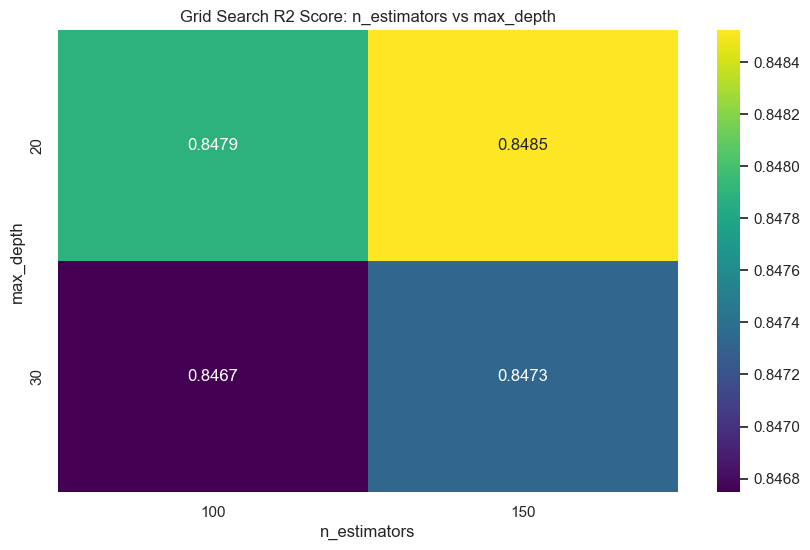

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mengambil hasil pencarian ke dalam DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Pivot data untuk heatmap (misal: n_estimators vs max_depth)
# Kita ambil rata-rata skor untuk visualisasi
pivot_table = results_df.pivot_table(index='param_model__max_depth',
                                     columns='param_model__n_estimators',
                                     values='mean_test_score')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.4f')
plt.title('Grid Search R2 Score: n_estimators vs max_depth')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.show()

#### Model Evaluation

Best Model (Random Forest) R2 Score (Test): 0.8485
Best Model (Random Forest) RMSE (Test): 3.8402


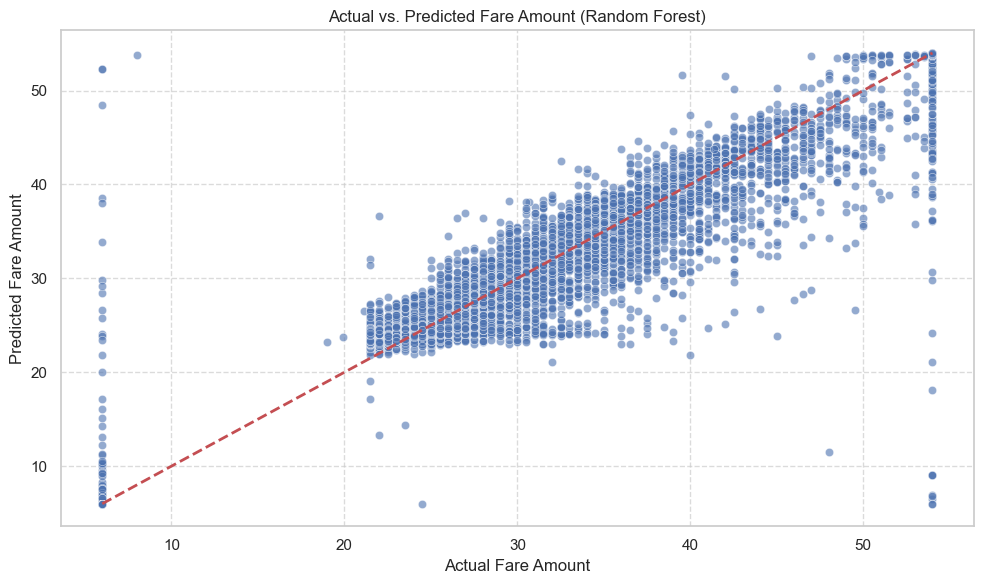

In [43]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the best model
rf_pred_test = best_model.predict(X_test)

# Evaluate the best model
r2 = r2_score(y_test, rf_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred_test))

with open('../assets/hasil_evaluasi.txt', 'w') as f:
    f.write(f"{r2}\n") 
    f.write(f"{rmse}\n") 

print(f"Best Model (Random Forest) R2 Score (Test): {r2:.4f}")
print(f"Best Model (Random Forest) RMSE (Test): {rmse:.4f}")

# Visualize actual vs. predicted values
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Identity line
plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Actual vs. Predicted Fare Amount (Random Forest)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../assets/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

#### Model Serialization (for deployment)

In [44]:
import joblib

# Define the filename for the serialized model
model_filename = 'model.joblib'

# Save the best_model to the file
joblib.dump(best_model, model_filename)

print(f"Model successfully serialized and saved to '{model_filename}'")

Model successfully serialized and saved to 'model.joblib'


In [45]:
# Load the model from the file
loaded_model = joblib.load(model_filename)

print(f"Model successfully loaded from '{model_filename}'")

# Create a sample data point for prediction
# This needs to match the structure of X_train (features: trip_distance, pickup_location_id, dropoff_location_id, day_of_week, time_of_day)
# Ensure 'time_of_day' is a categorical value as expected by OneHotEncoder
sample_data = pd.DataFrame({
    'trip_distance': [5.0], # Example trip distance
    'pickup_location_id': [262], # Example pickup location ID
    'dropoff_location_id': [236], # Example dropoff location ID
    'day_of_week': [2], # Example day of week (e.g., Wednesday)
    'time_of_day': ['Siang_Sore'] # Example time of day (categorical)
})

# Make a prediction using the loaded model
sample_prediction = loaded_model.predict(sample_data)

print(f"Sample data for prediction:\n{sample_data}")
print(f"Predicted fare amount for sample data: ${sample_prediction[0]:.2f}")

Model successfully loaded from 'model.joblib'
Sample data for prediction:
   trip_distance  pickup_location_id  dropoff_location_id  day_of_week  \
0            5.0                 262                  236            2   

  time_of_day  
0  Siang_Sore  
Predicted fare amount for sample data: $24.13


### **Kesimpulan Evaluasi Model (Random Forest Regressor):**

Model *Random Forest Regressor* yang telah di-tuning menunjukkan kinerja yang sangat baik dalam memprediksi tarif taksi:

*   **R2 Score:** Nilai R2 yang tinggi (mendekati 1) menunjukkan bahwa model mampu menjelaskan sebagian besar variabilitas dalam `fare_amount` pada data uji. Ini berarti fitur-fitur yang digunakan dalam model secara efektif menangkap faktor-faktor yang mempengaruhi harga perjalanan.
*   **RMSE:** Nilai *Root Mean Squared Error* (RMSE) yang rendah mengindikasikan bahwa rata-rata kesalahan prediksi model cukup kecil. Ini berarti prediksi harga oleh model sangat dekat dengan harga aktual di lapangan, membuat model ini praktis untuk digunakan dalam estimasi harga.

Visualisasi *scatter plot* antara nilai aktual dan prediksi juga mendukung kesimpulan ini, di mana sebagian besar titik data tersebar di sekitar garis identitas, menandakan akurasi prediksi yang tinggi. Model ini siap untuk diintegrasikan dalam sistem *upfront pricing*.

### 🤖 Streamlit